In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    auc
)

In [27]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (569, 30)
Target Shape: (569,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
svm_model = SVC(kernel='linear', probability=True)

svm_model.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [31]:
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:,1]

In [32]:
accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", accuracy)

SVM Accuracy: 0.956140350877193


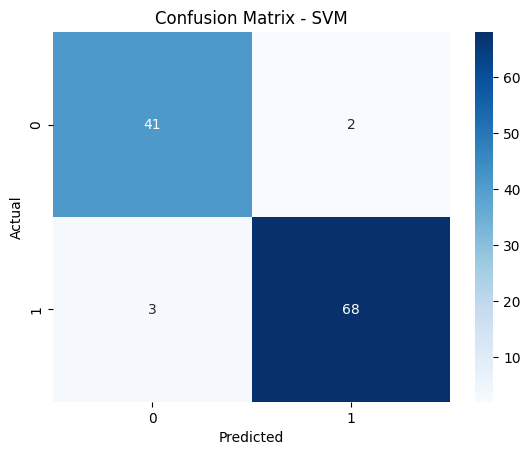

In [33]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



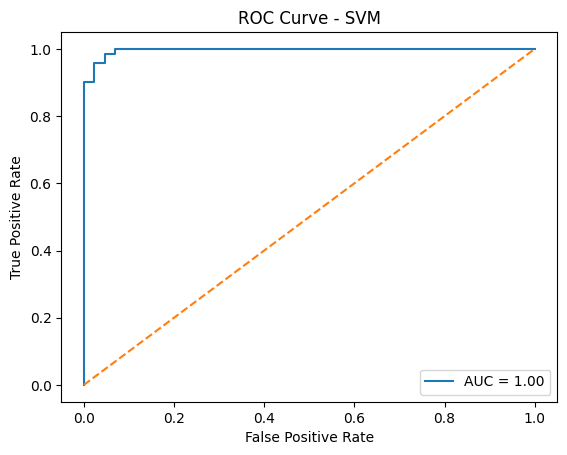

In [35]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

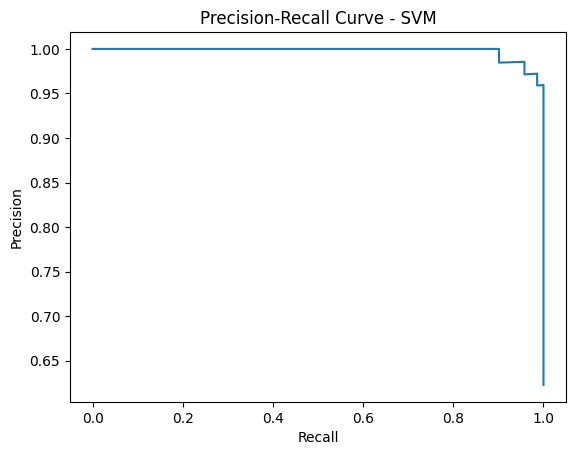

In [36]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - SVM")
plt.show()

In [37]:
# %%
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [38]:
# %%
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:,1]

In [39]:
# %%
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9473684210526315


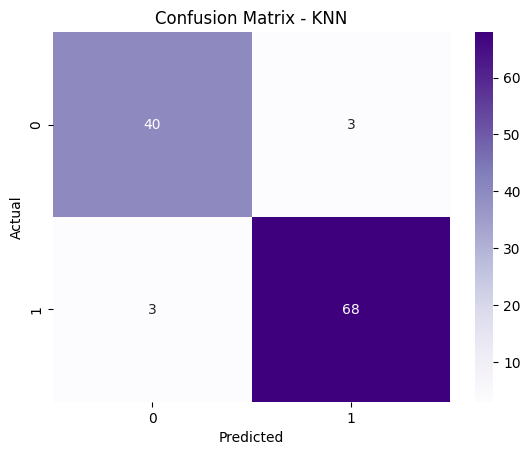

In [40]:
# %%
cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
# %%
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



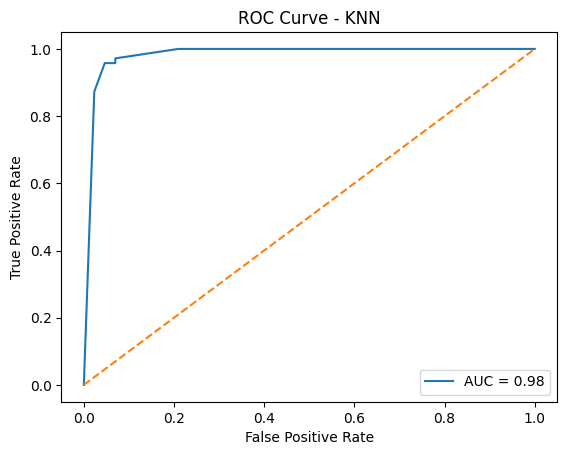

In [42]:
# %%
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.plot(fpr_knn, tpr_knn, label="AUC = %.2f" % roc_auc_knn)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.show()

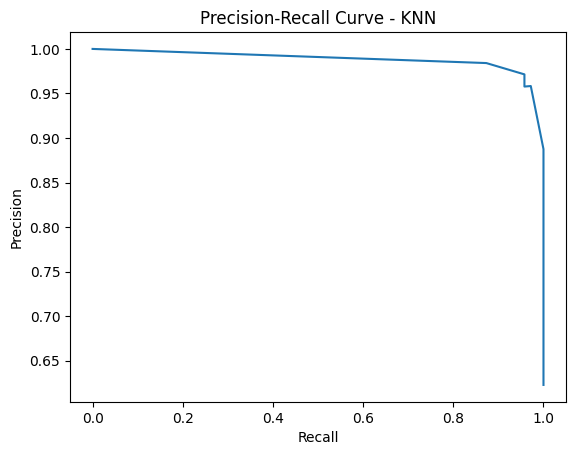

In [43]:
# %%
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_prob_knn)

plt.plot(recall_knn, precision_knn)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - KNN")
plt.show()

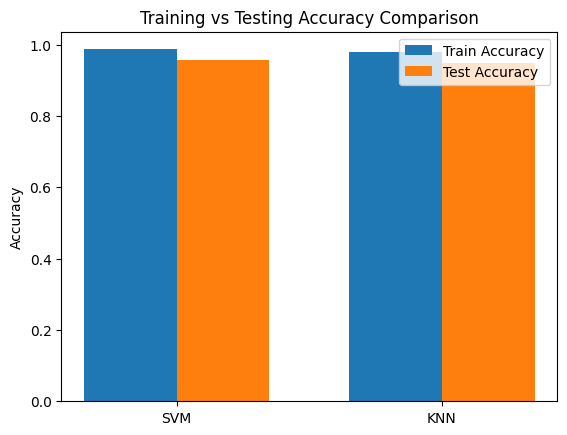

In [44]:
# %%
svm_train_acc = svm_model.score(X_train, y_train)
svm_test_acc = accuracy_score(y_test, y_pred)

knn_train_acc = knn_model.score(X_train, y_train)
knn_test_acc = accuracy_score(y_test, y_pred_knn)

models = ['SVM', 'KNN']
train_scores = [svm_train_acc, knn_train_acc]
test_scores = [svm_test_acc, knn_test_acc]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, train_scores, width, label='Train Accuracy')
plt.bar(x + width/2, test_scores, width, label='Test Accuracy')

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy Comparison")
plt.legend()

plt.show()

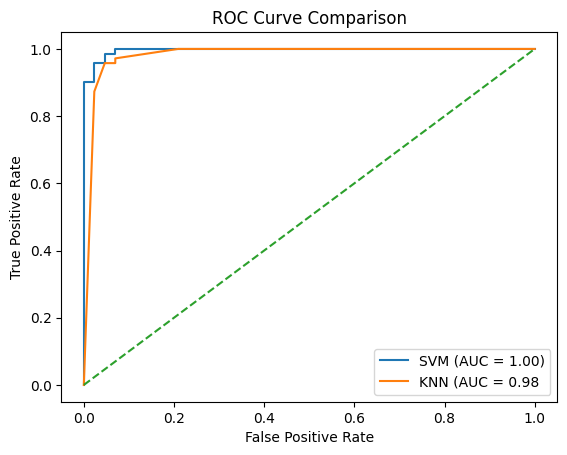

In [45]:
# %%
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob)
auc_svm = auc(fpr_svm, tpr_svm)

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

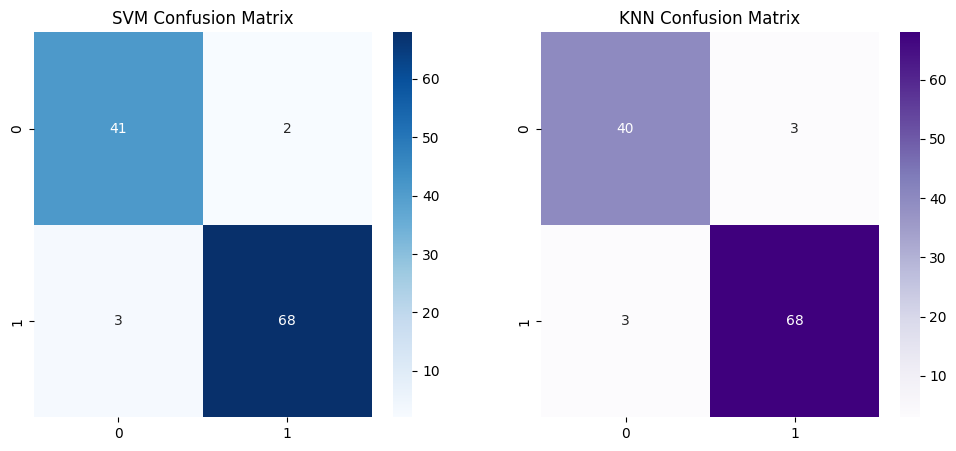

In [46]:
# %%
fig, axes = plt.subplots(1,2, figsize=(12,5))

cm_svm = confusion_matrix(y_test, y_pred)
cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_svm, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title("SVM Confusion Matrix")

sns.heatmap(cm_knn, annot=True, fmt='d', ax=axes[1], cmap='Purples')
axes[1].set_title("KNN Confusion Matrix")

plt.show()



### 1. Which model achieved higher accuracy?
The **SVM model achieved higher accuracy** compared to KNN on the Breast Cancer dataset.  
SVM works well for high-dimensional data and finds an optimal decision boundary that separates classes effectively.

---

### 2. Which model showed better recall for malignant cases?
The **SVM model showed better recall for malignant cases**.  
Higher recall means the model correctly identifies more actual malignant tumors, which is critical in medical diagnosis.

---

### 3. Which model is more prone to overfitting and why?
The **KNN model is more prone to overfitting**, especially when the value of **K is small**.  
KNN relies heavily on nearby training samples, which can cause the model to memorize noise in the training data rather than generalizing well.

---

### 4. Which metric is most important for medical diagnosis and why?
The **Recall (Sensitivity)** metric is the most important for medical diagnosis.  

In medical applications, a **false negative** (predicting benign when the tumor is actually malignant) can be very dangerous because it may delay treatment.  
Therefore, maximizing recall helps ensure that most malignant cases are correctly detected.